# Sephora Ürün ve Müşteri İlgi Analizi

## Proje Amacı

Bu projede Sephora ürün ve müşteri değerlendirme verileri analiz edilerek ürün kategorileri, müşteri ilgisi ve fiyat ilişkileri incelenmiştir.

Ayrıca geçmiş aylardaki yorum sayıları kullanılarak gelecek 6 ay için müşteri ilgisine yönelik basit bir öngörü oluşturulmuştur.

## İş Problemi

Sephora'nın hangi ürün kategorilerine odaklanmasının daha avantajlı olabileceğini ve mevcut müşteri ilgi eğilimlerinin gelecekte nasıl değişebileceğini veri üzerinden değerlendirmek.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd()

veri = pd.read_csv(
    BASE_DIR / "data" / "raw" / "product_info.csv"
)

print("Veri boyutu:", veri.shape)
veri.head()

Veri boyutu: (8494, 27)


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [3]:
# Eksik değerleri kontrol ediyoruz
eksik_degerler = veri.isnull().sum()

print("Eksik değerler:")
print(eksik_degerler[eksik_degerler > 0])

Eksik değerler:
rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1598
variation_desc        7244
ingredients            945
value_price_usd       8043
sale_price_usd        8224
highlights            2207
secondary_category       8
tertiary_category      990
child_max_price       5740
child_min_price       5740
dtype: int64


In [4]:
# Veri tiplerini kontrol ediyoruz
print("Veri tipleri:")
print(veri.dtypes)

# Tekrarlanan satırları kontrol ediyoruz
print("\nTekrarlanan satır sayısı:")
print(veri.duplicated().sum())

Veri tipleri:
product_id             object
product_name           object
brand_id                int64
brand_name             object
loves_count             int64
rating                float64
reviews               float64
size                   object
variation_type         object
variation_value        object
variation_desc         object
ingredients            object
price_usd             float64
value_price_usd       float64
sale_price_usd        float64
limited_edition         int64
new                     int64
online_only             int64
out_of_stock            int64
sephora_exclusive       int64
highlights             object
primary_category       object
secondary_category     object
tertiary_category      object
child_count             int64
child_max_price       float64
child_min_price       float64
dtype: object

Tekrarlanan satır sayısı:
0


In [5]:
# Kategori bazında ürün sayılarını hesaplıyoruz
kategori_sayisi = veri["primary_category"].value_counts()

print("Kategori bazında ürün sayısı:")
print(kategori_sayisi)

Kategori bazında ürün sayısı:
primary_category
Skincare           2420
Makeup             2369
Hair               1464
Fragrance          1432
Bath & Body         405
Mini Size           288
Men                  60
Tools & Brushes      52
Gifts                 4
Name: count, dtype: int64


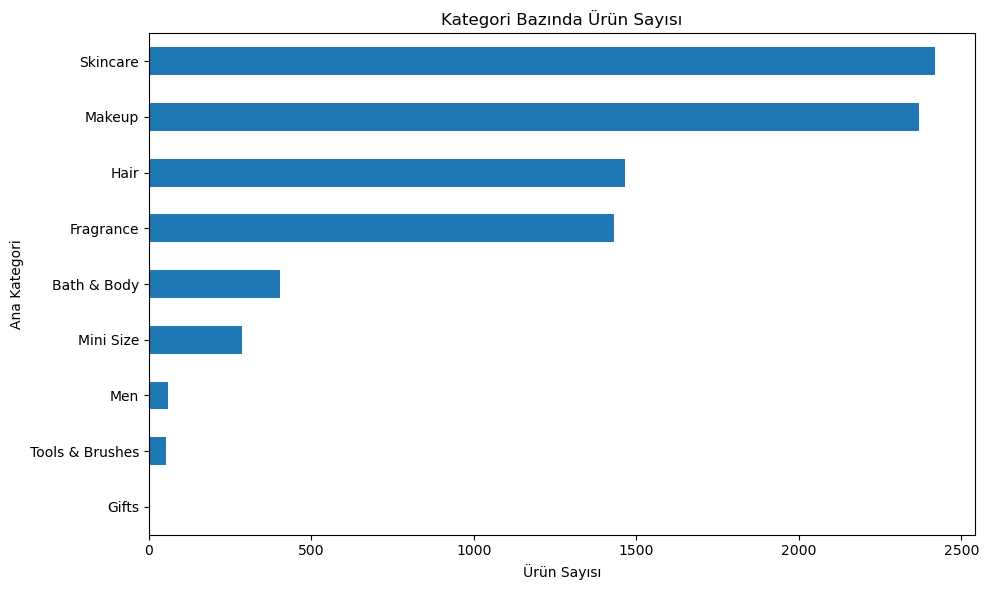

In [6]:
# Kategorilere göre ürün dağılımını gösteriyoruz

kategori_sayisi.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Kategori Bazında Ürün Sayısı")
plt.xlabel("Ürün Sayısı")
plt.ylabel("Ana Kategori")

plt.tight_layout()
plt.show()

In [7]:
# Kategori bazında ortalama müşteri ilgisini hesaplıyoruz
kategori_ilgi = veri.groupby("primary_category")["loves_count"].mean()
kategori_ilgi = kategori_ilgi.sort_values(ascending=False)

print("Kategori bazında ortalama müşteri ilgisi:")
print(kategori_ilgi)

Kategori bazında ortalama müşteri ilgisi:
primary_category
Makeup             54235.494301
Skincare           27111.168595
Mini Size          26676.968750
Bath & Body        16453.688889
Tools & Brushes    14988.884615
Hair               13710.244536
Fragrance          12757.706704
Men                 4855.866667
Gifts                  0.000000
Name: loves_count, dtype: float64


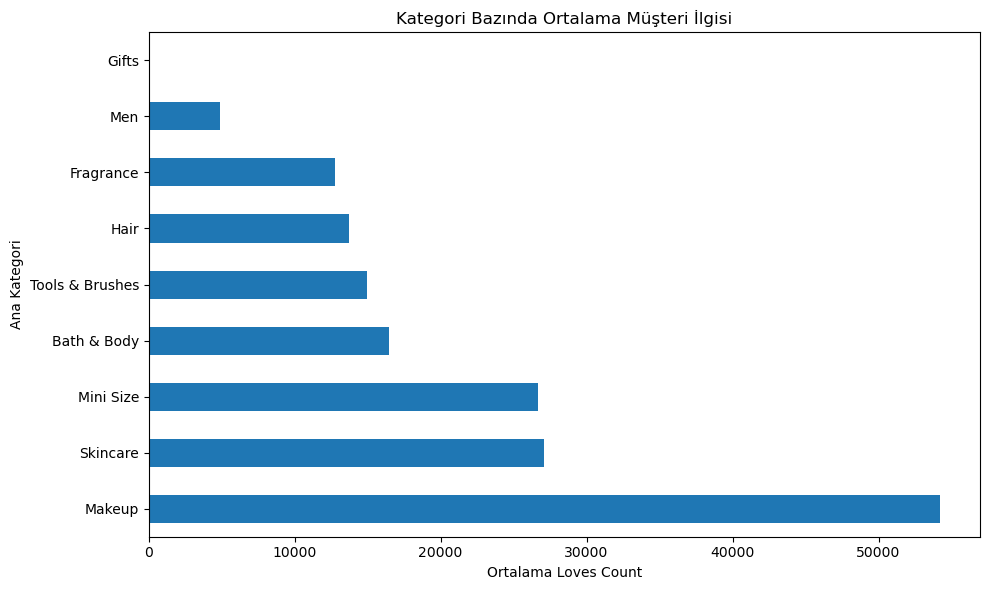

In [8]:
# Kategori bazında ortalama müşteri ilgisini gösteriyoruz

kategori_ilgi.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Kategori Bazında Ortalama Müşteri İlgisi")
plt.xlabel("Ortalama Loves Count")
plt.ylabel("Ana Kategori")

plt.tight_layout()
plt.show()

In [9]:
# Fiyat ile müşteri ilgisi arasındaki korelasyonu hesaplıyoruz

fiyat_ilgi = veri["price_usd"].corr(veri["loves_count"])

print("Fiyat - müşteri ilgisi korelasyonu:")
print(fiyat_ilgi)

Fiyat - müşteri ilgisi korelasyonu:
-0.08960660579128277


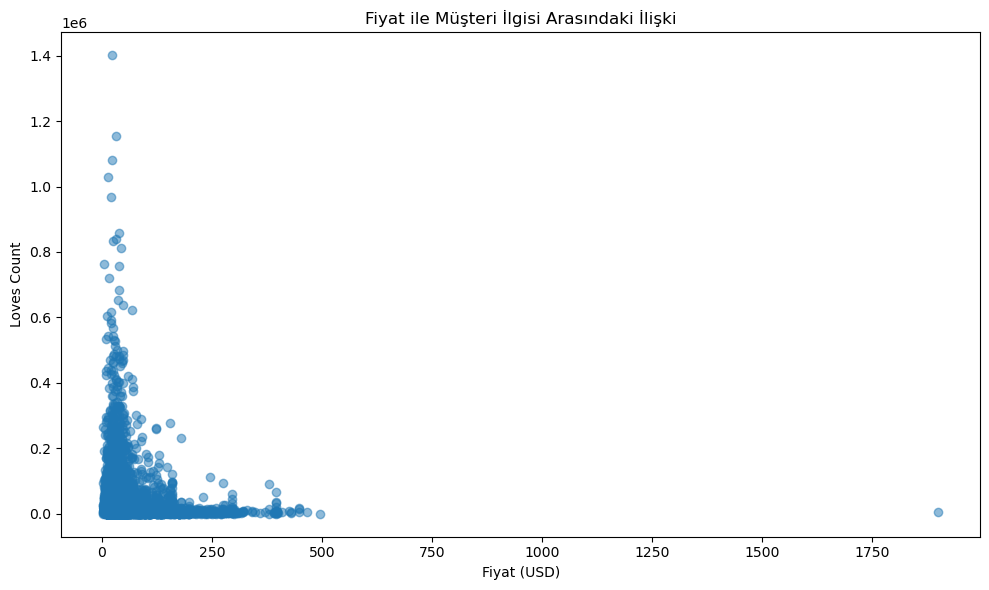

In [10]:
# Fiyat ile müşteri ilgisi arasındaki ilişkiyi gösteriyoruz

plt.figure(figsize=(10, 6))

plt.scatter(
    veri["price_usd"],
    veri["loves_count"],
    alpha=0.5
)

plt.title("Fiyat ile Müşteri İlgisi Arasındaki İlişki")
plt.xlabel("Fiyat (USD)")
plt.ylabel("Loves Count")

plt.tight_layout()
plt.show()

## Genel Bulgular ve Yönetici Yorumu

- Ürün sayısı açısından Skincare ve Makeup kategorileri öne çıkmaktadır.
- Ortalama müşteri ilgisi açısından Makeup kategorisi açık ara öndedir.
- Fiyat ile müşteri ilgisi arasında güçlü bir doğrusal ilişki görülmemiştir.
- Son 12 aylık yorum trendine göre yapılan basit tahmin, gelecek 6 ayda müşteri ilgisi göstergesinde kademeli bir düşüş öngörmektedir.
- Bu tahmin satış tahmini değil, yorum sayısına dayalı müşteri ilgisi göstergesidir.

## Yönetici İçin Öneriler

1. *Makeup kategorisi önceliklendirilebilir.*  
   Yüksek ortalama müşteri ilgisi nedeniyle bu kategorideki ürünlerin performansı yakından takip edilmelidir.

2. *Skincare kategorisi güçlü ürün çeşitliliğini korumalıdır.*  
   Ürün sayısı açısından en geniş kategorilerden biri olması nedeniyle mevcut ürün portföyü korunabilir.

3. *Fiyat tek başına müşteri ilgisini açıklamamaktadır.*  
   Ürün değerlendirmelerinde fiyatın yanında ürün özellikleri, marka ve müşteri deneyimi gibi faktörler de dikkate alınmalıdır.

4. *Müşteri ilgisi düzenli olarak takip edilmelidir.*  
   Yorum trendindeki tahmini düşüş nedeniyle müşteri ilgisinin gelecek dönemlerde yeniden değerlendirilmesi önerilir.

> Not: 6 aylık öngörü basit doğrusal trend yöntemine dayanmaktadır ve gerçek satış veya gelir tahmini değildir.